In [ ]:
# Install required libraries for audio processing and ML
!pip install librosa soundfile scikit-learn numpy pandas matplotlib tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"manavmandalia","key":"f786ad519ab8074bff146aeb47063395"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d abdulvahap/music-instrunment-sounds-for-classification


Dataset URL: https://www.kaggle.com/datasets/abdulvahap/music-instrunment-sounds-for-classification
License(s): apache-2.0
 99% 4.54G/4.59G [01:20<00:03, 20.2MB/s]
100% 4.59G/4.59G [01:20<00:00, 61.3MB/s]


In [ ]:
!unzip music-instrunment-sounds-for-classification.zip -d dataset/


Streaming output truncated to the last 5000 lines.
  inflating: dataset/music_dataset/Violin/53.wav  
  inflating: dataset/music_dataset/Violin/530.wav  
  inflating: dataset/music_dataset/Violin/531.wav  
  inflating: dataset/music_dataset/Violin/532.wav  
  inflating: dataset/music_dataset/Violin/533.wav  
  inflating: dataset/music_dataset/Violin/534.wav  
  inflating: dataset/music_dataset/Violin/535.wav  
  inflating: dataset/music_dataset/Violin/536.wav  
  inflating: dataset/music_dataset/Violin/537.wav  
  inflating: dataset/music_dataset/Violin/538.wav  
  inflating: dataset/music_dataset/Violin/539.wav  
  inflating: dataset/music_dataset/Violin/54.wav  
  inflating: dataset/music_dataset/Violin/540.wav  
  inflating: dataset/music_dataset/Violin/541.wav  
  inflating: dataset/music_dataset/Violin/542.wav  
  inflating: dataset/music_dataset/Violin/543.wav  
  inflating: dataset/music_dataset/Violin/544.wav  
  inflating: dataset/music_dataset/Violin/545.wav  
  inflating: da

In [ ]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root, len(files))


dataset 0
dataset/music_dataset 0
dataset/music_dataset/Bass_Guitar 3613
dataset/music_dataset/Trumpet 503
dataset/music_dataset/Keyboard 2041
dataset/music_dataset/Horn 1258
dataset/music_dataset/Shakers 1357
dataset/music_dataset/Mandolin 2458
dataset/music_dataset/Hi_Hats 444
dataset/music_dataset/Organ 1442
dataset/music_dataset/Banjo 2998
dataset/music_dataset/Floor_Tom 406
dataset/music_dataset/Drum_set 3648
dataset/music_dataset/Dobro 487
dataset/music_dataset/Harmonica 131
dataset/music_dataset/Ukulele 790
dataset/music_dataset/Accordion 3581
dataset/music_dataset/Violin 630
dataset/music_dataset/flute 3719
dataset/music_dataset/Clarinet 634
dataset/music_dataset/Tambourine 558
dataset/music_dataset/Electro_Guitar 1316
dataset/music_dataset/cowbell 621
dataset/music_dataset/Saxophone 454
dataset/music_dataset/Piano 575
dataset/music_dataset/Harmonium 1314
dataset/music_dataset/Cymbals 208
dataset/music_dataset/vibraphone 506
dataset/music_dataset/Trombone 2965
dataset/music_dat

In [ ]:
import librosa
import numpy as np
import pandas as pd
import os
from tqdm import tqdm


In [ ]:
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=22050, duration=5.0, mono=True)


        # MFCC
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
        mfcc_mean = np.mean(mfcc.T, axis=0)

        # Chroma
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)

        # Spectral Centroid
        centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))

        # Spectral Bandwidth
        bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))

        # Spectral Roll-off
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))

        # Zero Crossing Rate
        zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))

        # Combine features
        features = np.hstack([
            mfcc_mean,
            chroma_mean,
            centroid,
            bandwidth,
            rolloff,
            zcr
        ])
        return features

    except Exception as e:
        print("Error:", file_path, e)
        return None


In [ ]:
data = []
base = "dataset/music_dataset"

for folder in os.listdir(base):
    folder_path = os.path.join(base, folder)

    if os.path.isdir(folder_path):
        print("Processing:", folder)

        for file in tqdm(os.listdir(folder_path)):
            file_path = os.path.join(folder_path, file)

            features = extract_features(file_path)

            if features is not None:
                data.append([*features, folder])


Processing: Bass_Guitar


100%|██████████| 3613/3613 [04:35<00:00, 13.13it/s]


Processing: Trumpet


100%|██████████| 503/503 [00:32<00:00, 15.56it/s]


Processing: Keyboard


...

100%|██████████| 506/506 [00:32<00:00, 15.58it/s]


Processing: Trombone


100%|██████████| 2965/2965 [03:17<00:00, 15.02it/s]


Processing: Acoustic_Guitar


100%|██████████| 3654/3654 [04:13<00:00, 14.42it/s]


In [ ]:
columns = [f"mfcc_{i}" for i in range(20)] + \
          [f"chroma_{i}" for i in range(12)] + \
          ["centroid", "bandwidth", "rolloff", "zcr", "label"]

df = pd.DataFrame(data, columns=columns)


In [ ]:
df.to_csv("features_dataset.csv", index=False)


In [ ]:
import pandas as pd

df = pd.read_csv("features_dataset.csv")


In [ ]:
X = df.drop("label", axis=1)
y = df["label"]


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc)


Random Forest Accuracy: 0.9753042656268462


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


                 precision    recall  f1-score   support

      Accordion       0.95      0.99      0.97       716
Acoustic_Guitar       0.97      0.99      0.98       731
          Banjo       0.97      1.00      0.99       600
    Bass_Guitar       1.00      1.00      1.00       723
       Clarinet       0.97      0.98      0.97       127
        Cymbals       0.91      0.78      0.84        41
          Dobro       0.99      0.88      0.93        97
       Drum_set       1.00      1.00      1.00       730
 Electro_Guitar       0.99      0.93      0.96       263
      Floor_Tom       0.88      0.98      0.92        81
      Harmonica       1.00      0.88      0.94        26
      Harmonium       1.00      1.00      1.00       263
        Hi_Hats       0.89      0.93      0.91        89
           Horn       1.00      1.00      1.00       252
       Keyboard       1.00      1.00      1.00       408
       Mandolin       0.97      0.97      0.97       492
          Organ       0.98    

<Figure size 1600x1400 with 0 Axes>

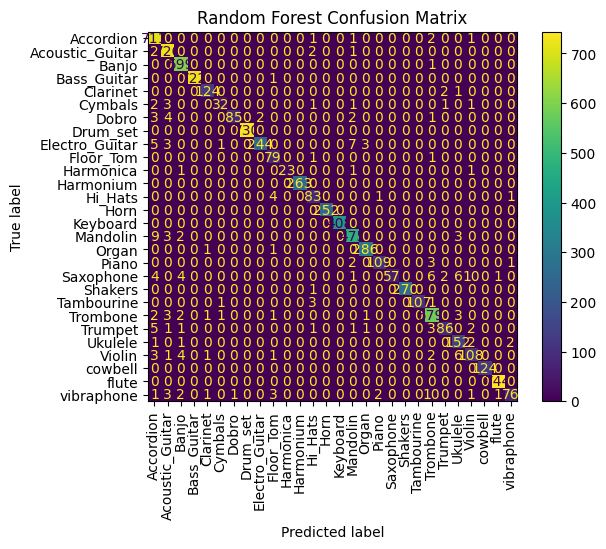

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(16,14))
disp = ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test, display_labels=le.classes_, xticks_rotation='vertical'
)
plt.title("Random Forest Confusion Matrix")
plt.show()


In [ ]:
import joblib

joblib.dump(rf, "instrument_classifier_random_forest.pkl")
joblib.dump(le, "label_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")


print("Model and label encoder saved successfully!")


Model and label encoder saved successfully!
